[*********************100%***********************]  1 of 1 completed


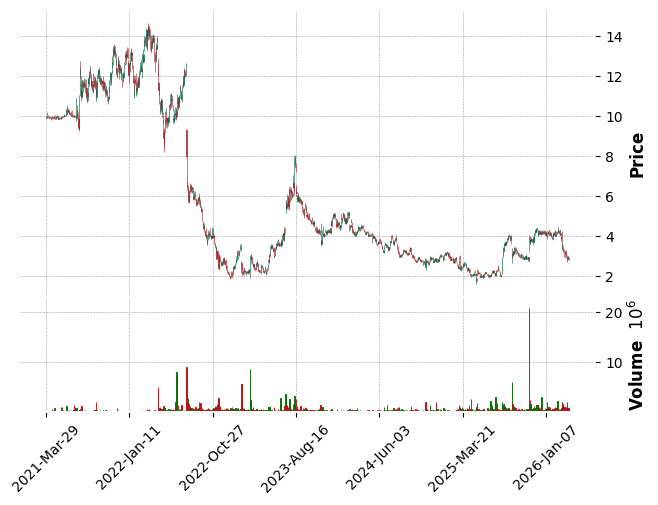

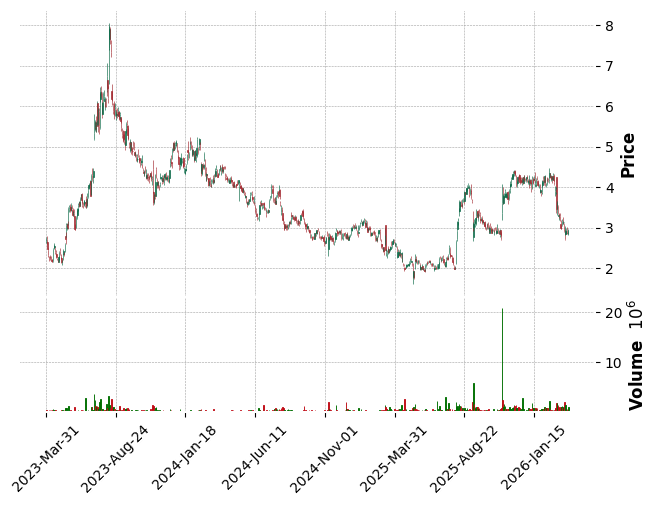

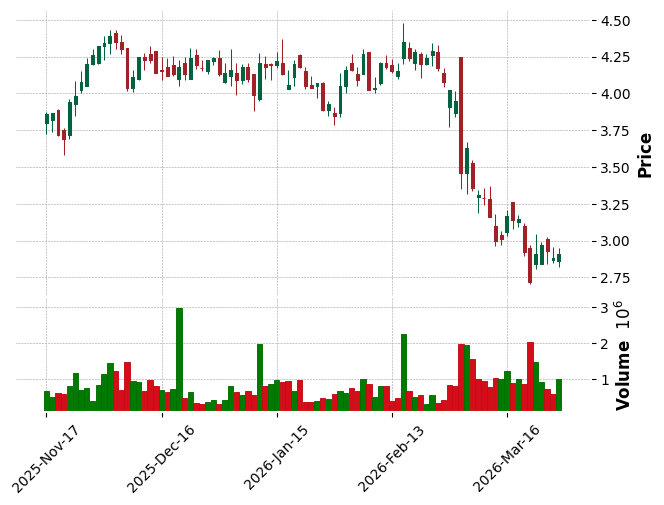

In [1]:
%load_ext autoreload
%autoreload 1
%aimport fundamentals

import finnhub
import pandas as pd
import json
from fundamentals import Fundamentals
import numpy as np
from itables import init_notebook_mode, options
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
import mplfinance as mpf
import ipynbname
init_notebook_mode(all_interactive=True)
options.style = "table-layout:auto; width:50%;"
plt.style.use('dark_background')
pd.set_option('display.float_format', '{:.2f}'.format)

# Setup client
# ASIX
name = ipynbname.name().strip('.ipynb').upper()
thirtyday = dt.datetime.now() - dt.timedelta(days=90)
Fun = Fundamentals(name, thirtyday.strftime('%Y-%m-%d'), dt.datetime.now().strftime('%Y-%m-%d'))

historical = Fun.get_history()
historical.columns = historical.columns.get_level_values(0)
mpf.plot(historical, type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-750:], type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-90:], type='candle', style='charles',volume=True)

In [2]:
funds = Fun.get_fundamentals()

funds

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


19.748181818181816


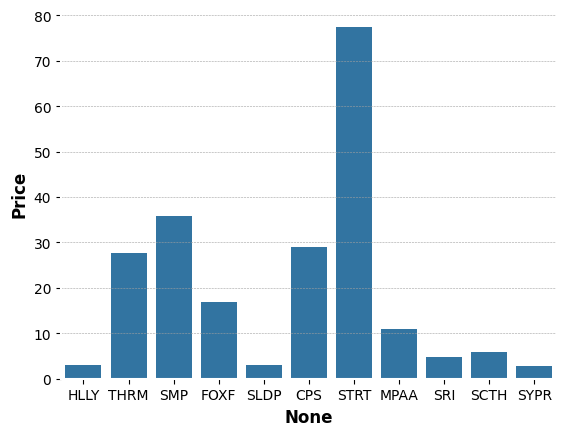

In [3]:
peers, avg_price = Fun.get_peers()
print(avg_price)
sns.barplot(x=peers.index, y=peers['Price'])
plt.show()

In [4]:
fairValues = Fun.caculateFairValues()

fairValues.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [5]:
other_metrics = Fun.get_other_metric()

other_metrics.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [6]:
insider_sentiment = Fun.get_insider_sentiment()
print(f"{insider_sentiment[0]}:")
print("")
print(insider_sentiment[1])

insider_signal:

No Recent Activity


In [7]:
news = Fun.get_news()

for x in news:
    print(x['datetime'])
    print(x['headline'])
    print(x['summary'])
    print(x['url'])
    print("")

2026-03-23 07:16:03
Shares of auto-related companies are trading higher, possibly amid a drop in the price of oil, which may raise demand.

https://finnhub.io/api/news?id=f8b71315a0398e9b81e1995744c2898572ba014e48b37939525ea54855fc3ace

2026-03-20 08:55:25
Holley: Shares Are Cheap, But I'd Like Them To Be Cheaper Still
Holley Inc. stock: why itâs still a Hold despite price dropsâgrowth drivers, cost cuts, debt reduction and 2026 guidance. Click for this HLLY earnings update.
https://finnhub.io/api/news?id=40e632be1b785ecafab21db076a91ae5751e0d1f11af15c81ad7aa733de83a22

2026-03-20 02:31:21
Holley Performance Brands Acquires HRX; Terms Not Disclosed

https://finnhub.io/api/news?id=01c27e9d7fa34377e78e8946caf1989c140fa8488e5f1116e31d4ecfbe616c9d

2026-03-06 11:12:01
Holley Inc. 2025 Q4 - Results - Earnings Call Presentation
2026-03-06. The following slide deck was published by Holley Inc.
https://finnhub.io/api/news?id=1de04b6fe170d782e1f9f5ee4fa9fc66bbd1e2ea5cc514d5fc6683593a50256d


Average Weighted EPS: 0.0204
Lower Standard Deviation: -0.12757170385508487
Upper Standard Deviation: 0.16837170385508488
Total Debt/Total Equity: 1.1642


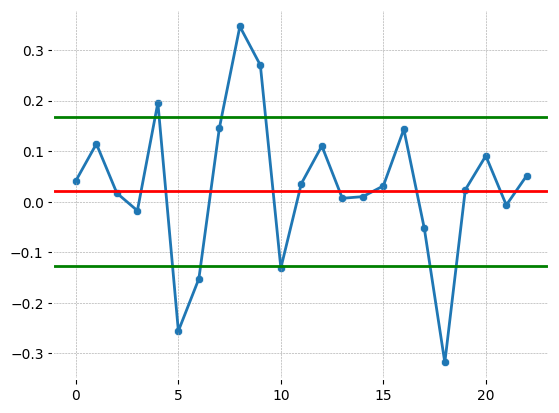

In [8]:
inflect = Fun.get_inflections()

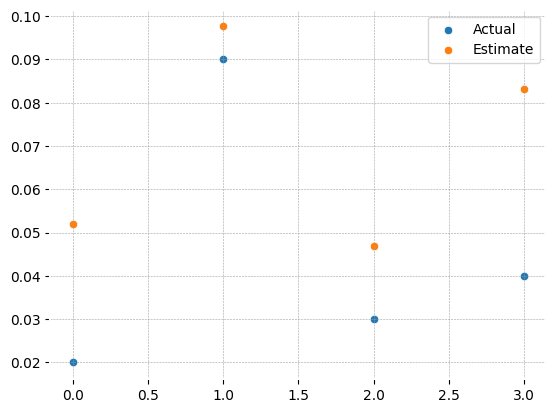

In [9]:
surprise = Fun.eps_surprise()

2021-12-31            NaN
2022-12-31   688415000.00
2023-12-31   659704000.00
2024-12-31   602224000.00
2025-12-31   613514000.00
Name: Total Revenue, dtype: float64
Revenue: [6.92847e+08 6.88415e+08 6.59704e+08 6.02224e+08 6.13514e+08]


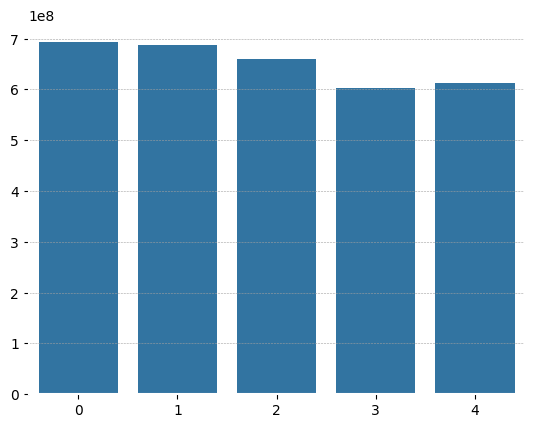

In [10]:
revenue = Fun.revenue_growth()

In [11]:
dcf = Fun.calculate_dcf()

Current FCF for HLLY: $13,669,000.00
{'Current Price': 2.91,
 'Enterprise Value': 197682703.24,
 'Intrinsic Price': -2.72,
 'Ticker': 'HLLY'}


--- Profitability Analysis: HLLY ---

Annual Net Income History:
2021-12-31            NaN
2022-12-31    73774000.00
2023-12-31    19180000.00
2024-12-31   -23235000.00
2025-12-31    19175000.00
Name: Net Income, dtype: float64

Last 4 Quarters Net Income:
2025-03-31    2817000.00
2025-06-30   10863000.00
2025-09-30    -806000.00
2025-12-31    6301000.00
Name: Net Income, dtype: float64


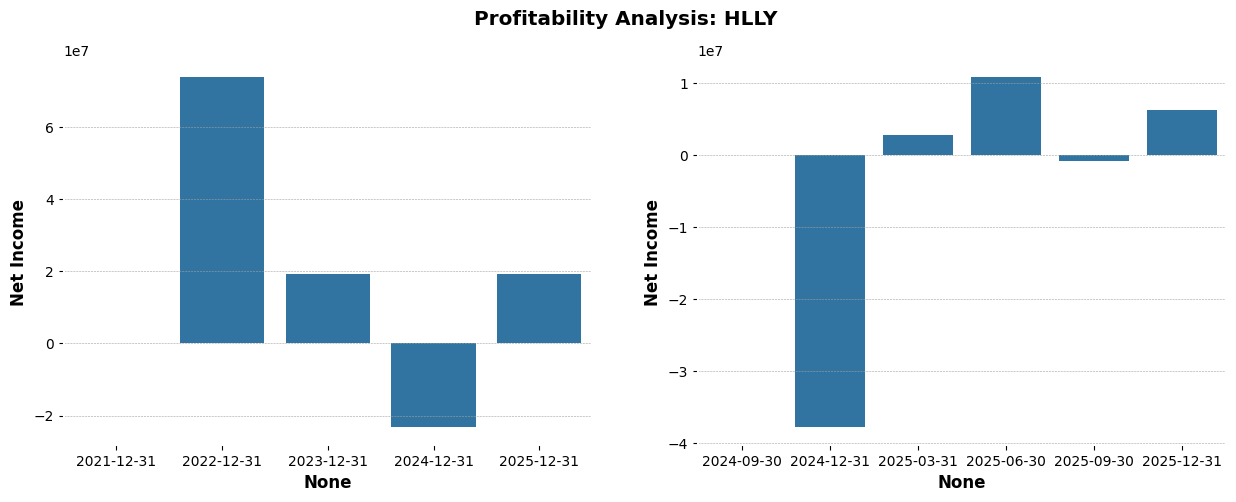

In [23]:
annual, quarterly = Fun.check_profitability()

